In [15]:
# importing require module
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
import requests
import pandas_datareader as web
from prophet.plot import plot_plotly
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
import datetime as dt

In [16]:
# getting the btc price data using yfinance
api_key = '6d14aa23444d48f29f7cd6c14ee62a19'
symbol = 'BTC/USD'
interval = '1h' # change this to 5min
order = 'asc'
start_date = '2022-09-01 00:00:00'
end_date = '2022-09-05 16:00:00'

api_url = f'https://api.twelvedata.com/time_series?symbol={symbol}&start_date={start_date}&end_date={end_date}&interval={interval}&order={order}&apikey={api_key}'
data = requests.get(api_url).json()
df = pd.DataFrame(data['values'])

In [17]:
# removing other column which will not be used
df.reset_index(inplace=True)
df = df[['datetime','close']]
df.columns = ['ds','y'] # prophet need the columns name as following to process
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'])

In [18]:
df

,ds,y
0,2022-09-01 00:00:00,20061.89062
1,2022-09-01 01:00:00,20124.82031
2,2022-09-01 02:00:00,20123.65039
3,2022-09-01 03:00:00,20016.33984
4,2022-09-01 04:00:00,20061.16016
...,...,...
108,2022-09-05 12:00:00,19725.03906
109,2022-09-05 13:00:00,19740.26953
110,2022-09-05 14:00:00,19845.36914
111,2022-09-05 15:00:00,19855.85938


In [19]:
# creating object of Prophet class
model = Prophet()

In [20]:
# fitting the dataframe in the model
model.fit(df)

19:23:10 - cmdstanpy - INFO - Chain [1] start processing
19:23:10 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
# making future data frame which will be predicted by the model
future_dates = model.make_future_dataframe(periods = 1, freq='h')
future_dates.tail()

,ds
109,2022-09-05 13:00:00
110,2022-09-05 14:00:00
111,2022-09-05 15:00:00
112,2022-09-05 16:00:00
113,2022-09-05 17:00:00


In [22]:
# predicting the future price of btc upto 1 hour
prediction = model.predict(future_dates)

In [23]:
# printing the prediction and the yhat is the predicted btc price
prediction.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
109,2022-09-05 13:00:00,19790.292962,19713.115380,19895.099202,19790.292962,19790.292962,15.280635,15.280635,15.280635,15.280635,15.280635,15.280635,0.0,0.0,0.0,19805.573597
110,2022-09-05 14:00:00,19787.043476,19711.977472,19890.322993,19787.043476,19787.043476,11.926687,11.926687,11.926687,11.926687,11.926687,11.926687,0.0,0.0,0.0,19798.970163
111,2022-09-05 15:00:00,19783.793990,19688.297783,19865.603122,19783.793990,19783.793990,-6.963160,-6.963160,-6.963160,-6.963160,-6.963160,-6.963160,0.0,0.0,0.0,19776.830830
112,2022-09-05 16:00:00,19780.544504,19655.573172,19820.752333,19780.544504,19780.544504,-39.567868,-39.567868,-39.567868,-39.567868,-39.567868,-39.567868,0.0,0.0,0.0,19740.976636
113,2022-09-05 17:00:00,19777.295017,19611.768128,19798.835776,19777.183231,19777.501869,-70.544778,-70.544778,-70.544778,-70.544778,-70.544778,-70.544778,0.0,0.0,0.0,19706.750240


In [24]:
prediction[['ds','yhat']].tail()

,ds,yhat
109,2022-09-05 13:00:00,19805.573597
110,2022-09-05 14:00:00,19798.970163
111,2022-09-05 15:00:00,19776.830830
112,2022-09-05 16:00:00,19740.976636
113,2022-09-05 17:00:00,19706.750240


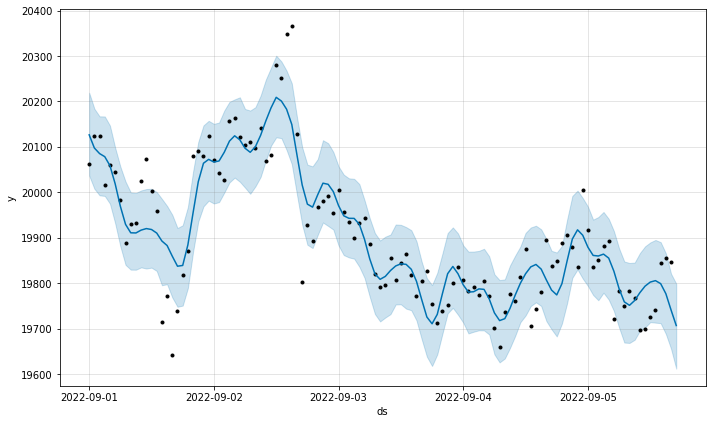

In [25]:
# ploting the prediction price in normal graph
fig = model.plot(prediction)
# the dark-blue line represent the predicted price, black dot show the actual price 
# and the blue range show the yhat_lower and yhat_upper

In [26]:
# ploting the predected price in more advance graph 
plot_plotly(model, prediction)

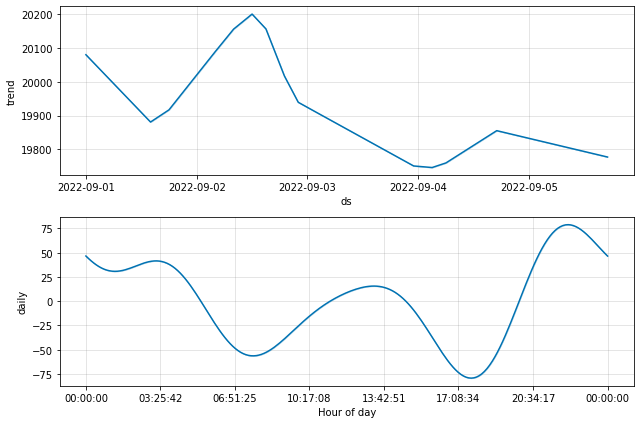

In [27]:
# ploting the graph which show the trend and weekly yearly data as well 
fig2 = model.plot_components(prediction)

In [28]:
# calculating the error in the prediction
df_cv = cross_validation(model, horizon='1 hour')

  0%|          | 0/175 [00:00<?, ?it/s]

19:23:36 - cmdstanpy - INFO - Chain [1] start processing
19:23:37 - cmdstanpy - INFO - Chain [1] done processing
19:23:38 - cmdstanpy - INFO - Chain [1] start processing
19:23:38 - cmdstanpy - INFO - Chain [1] done processing
19:23:39 - cmdstanpy - INFO - Chain [1] start processing
19:23:39 - cmdstanpy - INFO - Chain [1] done processing
19:23:41 - cmdstanpy - INFO - Chain [1] start processing
19:23:41 - cmdstanpy - INFO - Chain [1] done processing
19:23:42 - cmdstanpy - INFO - Chain [1] start processing
19:23:42 - cmdstanpy - INFO - Chain [1] done processing
19:23:44 - cmdstanpy - INFO - Chain [1] start processing
19:23:44 - cmdstanpy - INFO - Chain [1] done processing
19:23:45 - cmdstanpy - INFO - Chain [1] start processing
19:23:45 - cmdstanpy - INFO - Chain [1] done processing
19:23:46 - cmdstanpy - INFO - Chain [1] start processing
19:23:46 - cmdstanpy - INFO - Chain [1] done processing
19:23:47 - cmdstanpy - INFO - Chain [1] start processing
19:23:47 - cmdstanpy - INFO - Chain [1]

In [29]:
df_cv.tail()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
170,2022-09-05 14:00:00,19726.112563,19637.847735,19808.986262,19845.36914,2022-09-05 13:00:00
171,2022-09-05 14:00:00,19726.112563,19646.333504,19814.568454,19845.36914,2022-09-05 13:30:00
172,2022-09-05 15:00:00,19729.179863,19640.689954,19815.458168,19855.85938,2022-09-05 14:00:00
173,2022-09-05 15:00:00,19729.179863,19641.280028,19806.659939,19855.85938,2022-09-05 14:30:00
174,2022-09-05 16:00:00,19704.722917,19612.215688,19785.242441,19846.01953,2022-09-05 15:00:00


In [30]:
df_performance = performance_metrics(df_cv)

In [31]:
df_performance

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,0 days 00:30:00,12301.575725,110.912469,80.696049,0.004053,0.002609,0.004051,0.620690
1,0 days 01:00:00,12388.657055,111.304344,81.384692,0.004088,0.002649,0.004086,0.590909
